# Preprocess recipes for embedding

Turns the raw Food.com data into a clean, embeddable table. From the dataset
exploration we decided **1 recipe = 1 chunk**: each recipe becomes a single text
document (name + description + ingredients + instructions), well within an 8k-token
embedding context.

**Reviews** are used as a recomputed **quality signal** (count-weighted rating + review
count) attached to each recipe as metadata for filtering/re-ranking at retrieval time —
not embedded as separate documents.

Pipeline: **load → clean → build doc → dedup → reviews signal → (optional) sample → save**.

Set `SAMPLE_SIZE` to a small number while developing, then `None` for the full
~520k-recipe run (≈118M tokens, ≈\$2.4 on `text-embedding-3-small`).

### Config

In [12]:
from pathlib import Path

SAMPLE_SIZE = 5_000          # set to None to keep the full dataset
SEED = 42
PRIOR_STRENGTH = 10          # Bayesian shrinkage: ~how many "average" reviews to assume
OUT_DIR = Path("../data")    # repo root (notebook runs from notebooks/)
OUT_PATH = OUT_DIR / ("recipes_sample.parquet" if SAMPLE_SIZE else "recipes_clean.parquet")

### Load

In [13]:
import kagglehub
import pandas as pd
import numpy as np

path = Path(kagglehub.dataset_download("irkaal/foodcom-recipes-and-reviews"))
recipes = pd.read_parquet(path / "recipes.parquet")
reviews = pd.read_parquet(path / "reviews.parquet")
print(f"raw recipes: {len(recipes):,}  |  raw reviews: {len(reviews):,}")

raw recipes: 522,517  |  raw reviews: 1,401,982


### Clean

Drop rows that can't produce a useful embedding document: missing name or instructions.
Everything else (nutrition, ratings, etc.) is kept as metadata.

In [14]:
def join_arr(x):
    """Flatten an array-valued cell (ingredients / instructions) into one string."""
    if isinstance(x, (list, tuple, np.ndarray)):
        return " ".join(str(s) for s in x if s is not None)
    return "" if x is None else str(x)


df = recipes.copy()
df["Name"] = df["Name"].fillna("").astype(str).str.strip()
df["Description"] = df["Description"].fillna("").astype(str).str.strip()
df["ingredients_text"] = df["RecipeIngredientParts"].map(join_arr).str.strip()
df["instructions_text"] = df["RecipeInstructions"].map(join_arr).str.strip()

before = len(df)
df = df[(df["Name"] != "") & (df["instructions_text"] != "")]
print(f"dropped {before - len(df):,} rows missing name/instructions")
print(f"clean recipes: {len(df):,}")

dropped 3 rows missing name/instructions
clean recipes: 522,514


### Build the embedding document

One document per recipe. A light field-labelled template helps the embedding model
(and later, the LLM reading retrieved context) tell the parts apart.

In [15]:
def build_doc(row):
    parts = [row["Name"]]
    if row["Description"]:
        parts.append(row["Description"])
    if row["ingredients_text"]:
        parts.append("Ingredients: " + row["ingredients_text"])
    parts.append("Instructions: " + row["instructions_text"])
    return "\n".join(parts)


df["text"] = df.apply(build_doc, axis=1)
print(df["text"].iloc[0])

Low-Fat Berry Blue Frozen Dessert
Make and share this Low-Fat Berry Blue Frozen Dessert recipe from Food.com.
Ingredients: blueberries granulated sugar vanilla yogurt lemon juice
Instructions: Toss 2 cups berries with sugar. Let stand for 45 minutes, stirring occasionally. Transfer berry-sugar mixture to food processor. Add yogurt and process until smooth. Strain through fine sieve. Pour into baking pan (or transfer to ice cream maker and process according to manufacturers' directions). Freeze uncovered until edges are solid but centre is soft.  Transfer to processor and blend until smooth again. Return to pan and freeze until edges are solid. Transfer to processor and blend until smooth again. Fold in remaining 2 cups of blueberries. Pour into plastic mold and freeze overnight. Let soften slightly to serve.


### Deduplicate

Recipe *names* repeat (legit variants), so we don't dedup on name. We drop only exact
duplicate documents, which are true repeats that would skew retrieval.

In [16]:
before = len(df)
df = df.drop_duplicates(subset="text")
print(f"dropped {before - len(df):,} exact-duplicate documents")
print(f"unique recipes: {len(df):,}")

dropped 535 exact-duplicate documents
unique recipes: 521,979


### Reviews → quality signal

The dataset's precomputed `AggregatedRating` only matches a fresh recompute ~66% of the
time, so we recompute from the reviews table. Notes:

- **0-star reviews mean "commented without rating"** — excluded from the rating mean, but
  still counted as engagement (`review_count`).
- Ratings are heavily skewed to 5, and a single 5-star review shouldn't outrank a recipe
  with hundreds of reviews. We use a **count-weighted (Bayesian) rating** that shrinks
  low-volume recipes toward the global mean:

  `bayes = (v·R + m·C) / (v + m)`  where *R* = recipe mean, *v* = #ratings,
  *C* = global mean, *m* = `PRIOR_STRENGTH`.

Recipes with no ratings get `bayes = C` (treated as "average / unknown").

In [17]:
rated = reviews[reviews["Rating"] > 0]
global_mean = rated["Rating"].mean()

agg = reviews.groupby("RecipeId").agg(
    review_count=("ReviewId", "size"),
    n_ratings=("Rating", lambda s: (s > 0).sum()),
    mean_rating=("Rating", lambda s: s[s > 0].mean()),
)
agg["bayesian_rating"] = (
    (agg["n_ratings"] * agg["mean_rating"].fillna(global_mean) + PRIOR_STRENGTH * global_mean)
    / (agg["n_ratings"] + PRIOR_STRENGTH)
)

df = df.merge(agg, left_on="RecipeId", right_index=True, how="left")
df["review_count"] = df["review_count"].fillna(0).astype(int)
df["n_ratings"] = df["n_ratings"].fillna(0).astype(int)
df["bayesian_rating"] = df["bayesian_rating"].fillna(global_mean)
df["has_reviews"] = df["review_count"] > 0

print(f"global mean rating (excl. 0-star): {global_mean:.3f}")
print(f"recipes with >=1 review: {df['has_reviews'].mean():.1%}")
print(df[["mean_rating", "bayesian_rating", "review_count"]].describe().round(2))

global mean rating (excl. 0-star): 4.661
recipes with >=1 review: 52.0%
       mean_rating  bayesian_rating  review_count
count    265751.00        521979.00     521979.00
mean          4.58             4.66          2.69
std           0.63             0.08         14.45
min           1.00             3.14          0.00
25%           4.33             4.66          0.00
50%           4.88             4.66          1.00
75%           5.00             4.69          2.00
max           5.00             4.98       2892.00


### Parse durations → numeric minutes

`TotalTime` / `PrepTime` / `CookTime` are stored as ISO 8601 durations (`PT1H30M`), which
are great for display but useless as a **filter**. We parse them into plain integer
**minutes** so retrieval can enforce numeric constraints (e.g. "under 30 minutes").

Missing or unparseable values become `<NA>` (pandas nullable integer) and simply won't
match a numeric filter later. These new columns ride along into the parquet — they are
metadata, **not** part of the embedded `text`, so adding them never requires re-embedding.

In [18]:
import re

# ISO 8601 duration: P[nD]T[nH][nM][nS]  (Food.com only ever uses the time part)
_DUR_RE = re.compile(
    r"P(?:(?P<days>\d+)D)?T(?:(?P<hours>\d+)H)?(?:(?P<minutes>\d+)M)?(?:(?P<seconds>\d+)S)?"
)


def iso_duration_to_minutes(s):
    """ISO 8601 duration ('PT1H30M') -> total minutes (int), or None if unparseable/empty."""
    if not isinstance(s, str) or not s.strip():
        return None
    m = _DUR_RE.fullmatch(s.strip())
    if not m:
        return None
    days = int(m["days"] or 0)
    hours = int(m["hours"] or 0)
    minutes = int(m["minutes"] or 0)
    seconds = int(m["seconds"] or 0)
    total = days * 1440 + hours * 60 + minutes + round(seconds / 60)
    return total or None


duration_cols = {
    "TotalTime": "total_time_minutes",
    "PrepTime": "prep_time_minutes",
    "CookTime": "cook_time_minutes",
}
for src, dst in duration_cols.items():
    df[dst] = df[src].map(iso_duration_to_minutes).astype("Int64")

preview = ["TotalTime", "total_time_minutes", "PrepTime", "prep_time_minutes", "CookTime", "cook_time_minutes"]
print(df[preview].head())
print("\ntotal_time_minutes summary:")
print(df["total_time_minutes"].describe())
print(f"\nunparseable / missing total_time: {df['total_time_minutes'].isna().sum():,}")

  TotalTime  total_time_minutes PrepTime  prep_time_minutes CookTime  \
0  PT24H45M                1485    PT45M                 45    PT24H   
1   PT4H25M                 265     PT4H                240    PT25M   
2     PT35M                  35    PT30M                 30     PT5M   
3  PT24H20M                1460    PT24H               1440    PT20M   
4     PT50M                  50    PT20M                 20    PT30M   

   cook_time_minutes  
0               1440  
1                 25  
2                  5  
3                 20  
4                 30  

total_time_minutes summary:
count        519849.0
mean       255.677133
std      62572.734177
min               1.0
25%              20.0
50%              40.0
75%              70.0
max        43552800.0
Name: total_time_minutes, dtype: Float64

unparseable / missing total_time: 2,130


### Fix fake-zero nutrition

Food.com stores "nutrition never calculated" as an **all-zero row**, not as missing. That
breaks numeric filters: `Calories < 500` matches every fake-zero (`0 < 500`), flooding
results with junk recipes that only *look* low-calorie. We set those rows to `NaN`, which
fails every comparison (`NaN < 500` is `False`), so they drop out of range filters instead
of always matching.

**Trigger = all 9 nutrition fields are 0**, not just `Calories == 0`. Only ~80% of
`Calories == 0` rows are truly uncomputed; the other ~20% were measured and genuinely have
0 kcal with real sodium (brines, seasoning salts, teas) — nuking those would wrongly hide
real low-calorie recipes. Legit macro-zeros (`Calories > 0`, e.g. alcohol: calories but ~0
protein/carb/fat) stay untouched. `total_time_minutes` is already clean; negatives/outliers
are out of scope (there are none).

In [19]:
# Food.com encodes "nutrition never calculated" as an all-zero row, not as missing. That
# breaks numeric filters (0 passes any "< threshold"), so we NaN those rows: NaN fails
# every comparison, dropping them out of range filters instead of always matching.
# We require ALL 9 fields == 0, not just Calories == 0: a measured row can genuinely have
# 0 kcal with real sodium (brines, seasoning salts, teas) and must stay. Legit macro-zeros
# (Calories > 0, e.g. alcohol: calories but ~0 protein/carb/fat) are untouched either way.
nutrition_cols = [
    "Calories", "FatContent", "SaturatedFatContent", "CholesterolContent",
    "SodiumContent", "CarbohydrateContent", "FiberContent", "SugarContent",
    "ProteinContent",
]
macros = ["ProteinContent", "CarbohydrateContent", "FatContent"]

fake = (df[nutrition_cols] == 0).all(axis=1)
legit_before = ((df["Calories"] > 0) & (df[macros] == 0).all(axis=1)).sum()

df.loc[fake, nutrition_cols] = np.nan

assert not (df[nutrition_cols] == 0).all(axis=1).any(), "all-zero rows should be gone"
legit_after = ((df["Calories"] > 0) & (df[macros] == 0).all(axis=1)).sum()
assert legit_after == legit_before, "legit macro-zeros must survive"
print(f"nulled {fake.sum():,} all-zero nutrition rows -> NaN; kept {legit_after:,} legit macro-zeros (alcohol)")

nulled 2,481 all-zero nutrition rows -> NaN; kept 978 legit macro-zeros (alcohol)


### Stratified sample (dev only)

When `SAMPLE_SIZE` is set, take a sample stratified by category and whether the recipe
has reviews, so the dev set mirrors the full distribution instead of over-representing
the dominant categories. With `SAMPLE_SIZE = None` the full dataset passes through.

In [20]:
df["RecipeCategory"] = df["RecipeCategory"].fillna("Unknown")

if SAMPLE_SIZE and SAMPLE_SIZE < len(df):
    frac = SAMPLE_SIZE / len(df)
    sampled = df.groupby(
        ["RecipeCategory", "has_reviews"], observed=True
    ).sample(frac=frac, random_state=SEED)
    df_out = sampled.sample(n=min(SAMPLE_SIZE, len(sampled)), random_state=SEED)
    print(f"stratified sample: {len(df_out):,} of {len(df):,}")
else:
    df_out = df
    print(f"full dataset: {len(df_out):,}")

stratified sample: 4,983 of 521,979


### Check the sample mirrors the full dataset

`RecipeCategory` and `has_reviews` match the full set **by construction** (we stratified
on them). The real question is whether the variables we *didn't* stratify on survived the
sampling. We plot them as **densities** (area = 1) so the small sample and the full set
overlap despite the ~100x size gap — if the shapes line up, the sample is representative.

has_reviews share   full: 52.0%   sample: 52.0%


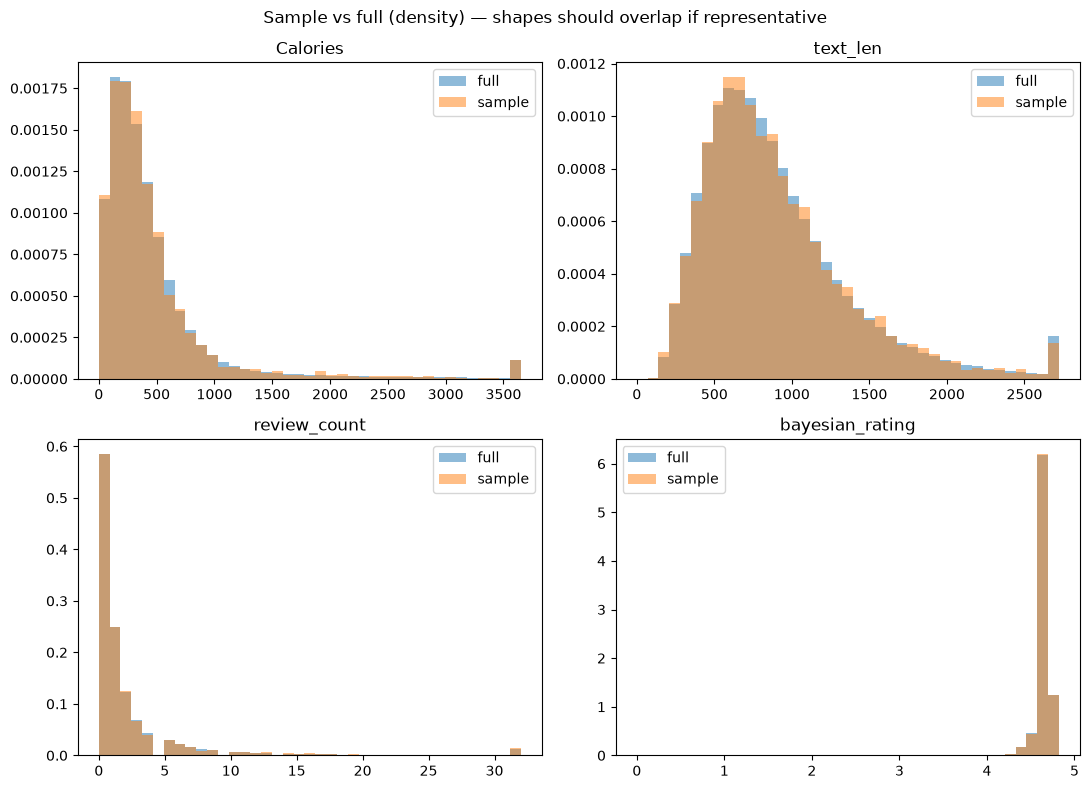

In [21]:
import matplotlib.pyplot as plt

df_out = df_out.copy()
df["text_len"] = df["text"].str.len()
df_out["text_len"] = df_out["text"].str.len()

check_cols = ["Calories", "text_len", "review_count", "bayesian_rating"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for col, ax in zip(check_cols, axes.flat):
    hi = df[col].quantile(0.99)
    bins = np.linspace(0, hi, 40)
    ax.hist(df[col].clip(upper=hi), bins=bins, density=True, alpha=0.5, label="full")
    ax.hist(df_out[col].clip(upper=hi), bins=bins, density=True, alpha=0.5, label="sample")
    ax.set_title(col)
    ax.legend()

fig.suptitle("Sample vs full (density) — shapes should overlap if representative")
fig.tight_layout()

print(f"has_reviews share   full: {df['has_reviews'].mean():.1%}   sample: {df_out['has_reviews'].mean():.1%}")

### Save

In [ ]:
# Keep everything: Qdrant becomes the single source of truth (nutrition, images,
# times, ...). Only drop the intermediate helper columns already folded into `text`.
helper_cols = ["ingredients_text", "instructions_text", "text_len"]
out = df_out.drop(columns=helper_cols, errors="ignore").reset_index(drop=True)

# RecipeId arrives as float64 from the raw parquet. Cast to int so it stays a clean
# join key: Qdrant MatchAny needs int, not 336672.0, when the reviews collection is
# prefiltered by RecipeId.
out["RecipeId"] = out["RecipeId"].astype("int64")

OUT_DIR.mkdir(parents=True, exist_ok=True)
out.to_parquet(OUT_PATH, index=False)

tok = out["text"].str.len().sum() / 4  # rough ~chars/4 token estimate
print(f"wrote {len(out):,} recipes ({out.shape[1]} columns) -> {OUT_PATH}")
print(f"~{tok / 1e6:.1f}M tokens  (~${tok / 1e6 * 0.02:.2f} on text-embedding-3-small)")
out.head()